In [1]:
import os
os.chdir('../..')

In [2]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from loguru import logger
from src.datasets import MaterialsProject

/Users/karlfindhansen/Desktop/DTU/Kandidat/Thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-02-17 14:53:58.631 | INFO     | utils.file_ops:get_device:36 - Using Apple Silicon (MPS)


In [4]:
mp = MaterialsProject()
mp.load(force_fetch=True)

2026-02-17 14:54:05.978 | INFO     | src.datasets:_fetch_from_api:344 - Fetching 1000 stable oxides from API...
Retrieving SummaryDoc documents: 100%|██████████| 10325/10325 [00:11<00:00, 911.42it/s]
2026-02-17 14:54:20.738 | SUCCESS  | src.datasets:_fetch_from_api:397 - Dataset saved with 1000 entries.


material_id,formula_pretty,energy_per_atom,formation_energy_per_atom,raw_structure,crystal_system,space_group,density,a,b,c,alpha,beta,gamma,volume,num_sites
str,str,f64,f64,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,i64
"""mp-1274279""","""FeO""",-8.19051,-1.481519,"""{""@module"": ""pymatgen.core.str…","""Monoclinic""","""C2/m""",5.614899,3.102294,5.375696,5.443817,110.556657,91.096992,89.9466,84.988477,8
"""mp-19921""","""PbO""",-5.800276,-1.469972,"""{""@module"": ""pymatgen.core.str…","""Tetragonal""","""P4/nmm""",8.810225,3.999514,3.999514,5.259816,90.0,90.0,90.0,84.136627,4
"""mp-2097""","""SnO""",-6.108469,-1.629702,"""{""@module"": ""pymatgen.core.str…","""Tetragonal""","""P4/nmm""",6.294343,3.813695,3.813695,4.8869133,90.0,90.0,90.0,71.076593,4
"""mp-1692""","""CuO""",-5.466379,-0.942795,"""{""@module"": ""pymatgen.core.str…","""Tetragonal""","""P4_2/mmc""",6.1556,2.879501,2.879545,5.176397,89.806512,89.806349,89.222525,42.916449,4
"""mp-1336""","""PdO""",-5.853748,-0.789826,"""{""@module"": ""pymatgen.core.str…","""Tetragonal""","""P4_2/mmc""",8.117606,3.053604,3.053604,5.371257,90.0,90.0,90.0,50.084274,4
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""mp-24129""","""MnH4(BrO)2""",-5.299537,-1.309259,"""{""@module"": ""pymatgen.core.str…","""Monoclinic""","""C2/m""",2.976894,3.963651,6.006202,6.006203,95.912312,96.949439,96.949428,139.885532,9
"""mp-23880""","""FeH4(ClO)2""",-5.265791,-1.305381,"""{""@module"": ""pymatgen.core.str…","""Monoclinic""","""C2/m""",2.287095,5.714367,5.714367,3.721117,82.486963,82.486963,97.148948,118.187118,9
"""mp-23853""","""CoH4(ClO)2""",-5.045306,-1.233407,"""{""@module"": ""pymatgen.core.str…","""Monoclinic""","""C2/m""",2.424991,3.603494,5.686069,5.686069,97.465063,96.908777,96.908772,113.58114,9


In [7]:
mp.df["raw_structure"][0]

'{"@module": "pymatgen.core.structure", "@class": "Structure", "charge": 0, "lattice": {"matrix": [[2.176648, -2.210439, -0.019736], [2.157691, 2.157191999999999, -4.425946], [2.163513, 2.236831, 4.466648]], "pbc": [true, true, true], "a": 3.1022937640270305, "b": 5.375695840657374, "c": 5.443817206669784, "alpha": 110.55665728789754, "beta": 91.09699169817493, "gamma": 89.9466003593816, "volume": 84.98847683834407}, "properties": {}, "sites": [{"species": [{"element": "Fe", "occu": 1}], "abc": [0.5, 0.0, 0.5], "properties": {"magmom": -3.73}, "label": "Fe", "xyz": [2.1700805, 0.013195999999999986, 2.223456]}, {"species": [{"element": "Fe", "occu": 1}], "abc": [0.0, 0.5, 0.5], "properties": {"magmom": -3.727}, "label": "Fe", "xyz": [2.160602, 2.1970114999999995, 0.02035100000000023]}, {"species": [{"element": "Fe", "occu": 1}], "abc": [0.0, 0.0, 0.0], "properties": {"magmom": 3.73}, "label": "Fe", "xyz": [0.0, 0.0, 0.0]}, {"species": [{"element": "Fe", "occu": 1}], "abc": [0.500001, 0.

# Plots for investegating

In [8]:
def plot_materials_data(df: pl.DataFrame):
    """
    Generates plots for Materials Project data using a Polars DataFrame.
    """
    logger.info("Starting visualization of Materials Project data...")

    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    logger.info("Generating Crystal System distribution plot...")
    crystal_counts = (
        df.group_by("crystal_system")
        .len()
        .sort("len", descending=True)
    )

    sns.barplot(
        ax=axes[0],
        x=crystal_counts["crystal_system"].to_list(),
        y=crystal_counts["len"].to_list(),
    )

    axes[0].set_title("Materials Project: Diversity of Crystal Systems", fontsize=14)
    axes[0].set_xlabel("Crystal System", fontsize=12)
    axes[0].set_ylabel("Count", fontsize=12)
    axes[0].tick_params(axis='x', rotation=45)

    logger.info("Generating Stability Landscape scatter plot...")
    sns.scatterplot(
        ax=axes[1],
        data=df.to_pandas(), 
        x='formation_energy_per_atom', 
        y='energy_per_atom', 
        hue='crystal_system', 
        palette="viridis", 
        s=50, 
        alpha=0.7
    )
    axes[1].set_title("Materials Project: Stability Landscape (Oxides)", fontsize=14)
    axes[1].set_xlabel("Formation Energy (eV/atom)", fontsize=12)
    axes[1].set_ylabel("Energy per Atom (eV/atom)", fontsize=12)
    axes[1].legend(title="Symmetry", bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

    logger.info("Generating Volume Distribution plot...")
    plt.figure(figsize=(10, 6))
    sns.kdeplot(
        data=df.to_pandas(), 
        x='volume', 
        hue='crystal_system', 
        fill=True, 
        common_norm=False, 
        alpha=0.3
    )
    plt.title("Materials Project: Lattice Volume Distribution by Crystal System", fontsize=14)
    plt.xlabel("Lattice Volume (Å³)", fontsize=12)
    plt.ylabel("Density", fontsize=12)
    plt.show()

    logger.success("Visualization complete.")

2026-02-17 14:59:33.232 | INFO     | __main__:plot_materials_data:5 - Starting visualization of Materials Project data...
2026-02-17 14:59:33.281 | INFO     | __main__:plot_materials_data:10 - Generating Crystal System distribution plot...
2026-02-17 14:59:33.358 | INFO     | __main__:plot_materials_data:28 - Generating Stability Landscape scatter plot...


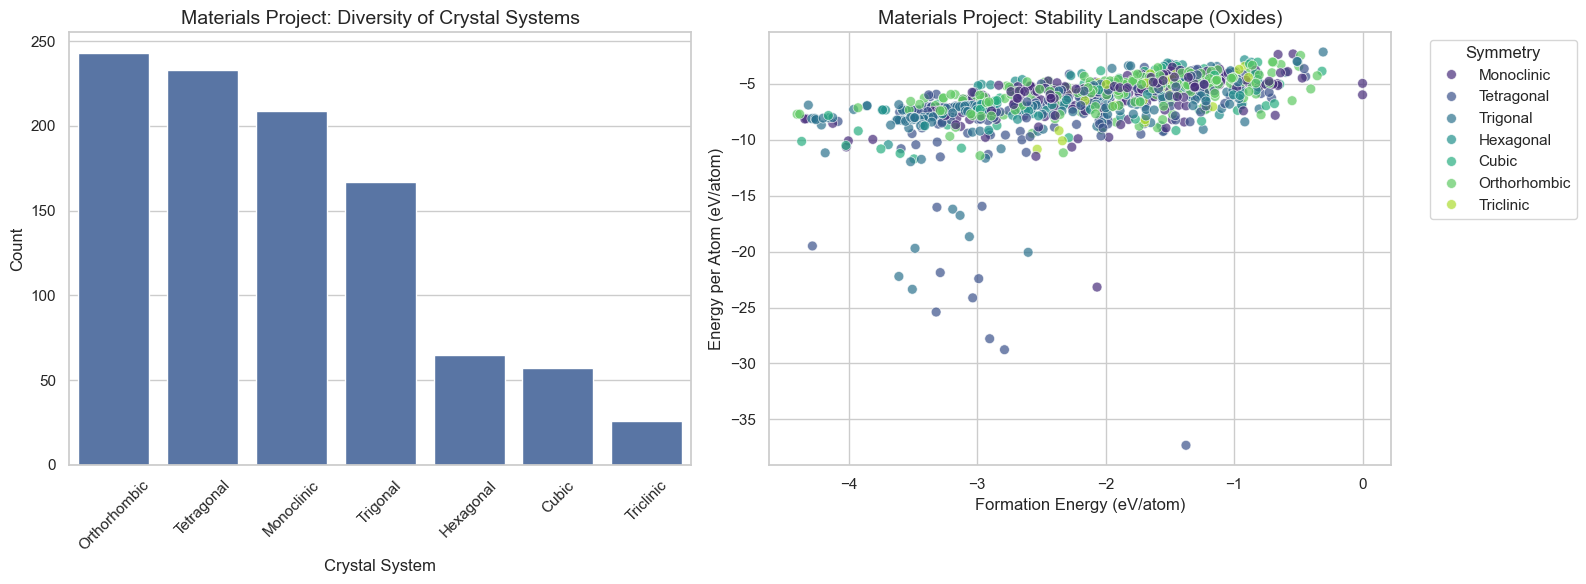

2026-02-17 14:59:33.492 | INFO     | __main__:plot_materials_data:47 - Generating Volume Distribution plot...


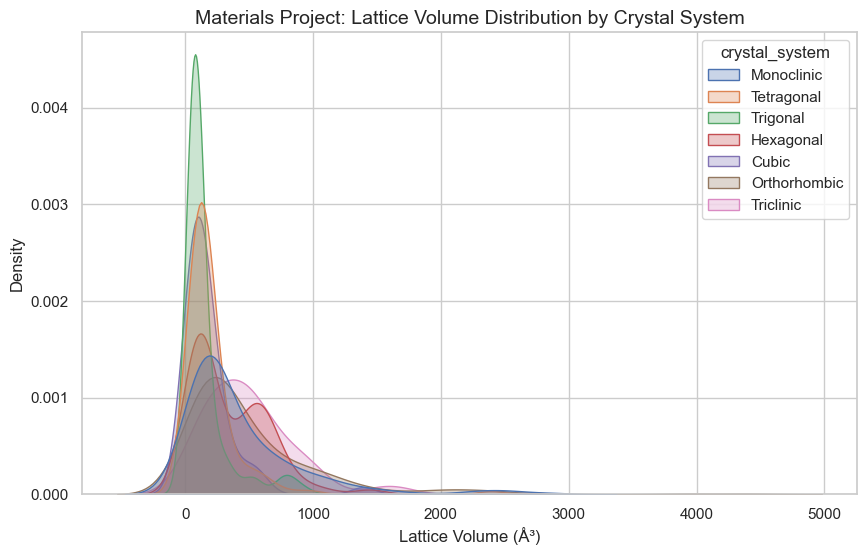

2026-02-17 14:59:33.578 | SUCCESS  | __main__:plot_materials_data:62 - Visualization complete.


In [9]:
plot_materials_data(mp.df)